../results/retrieved_docs_medqa_qwenagent: sufficient=2207, ../results/question_categories_cleaned.csv after subset=2207
../results/retrieved_docs_pubmed_qwenagent: sufficient=437, ../results/question_categories_pubmed_cleaned.csv after subset=437
Combined questions: 2644
Saved → ../plots/dermatology_radial_tree_combined.png


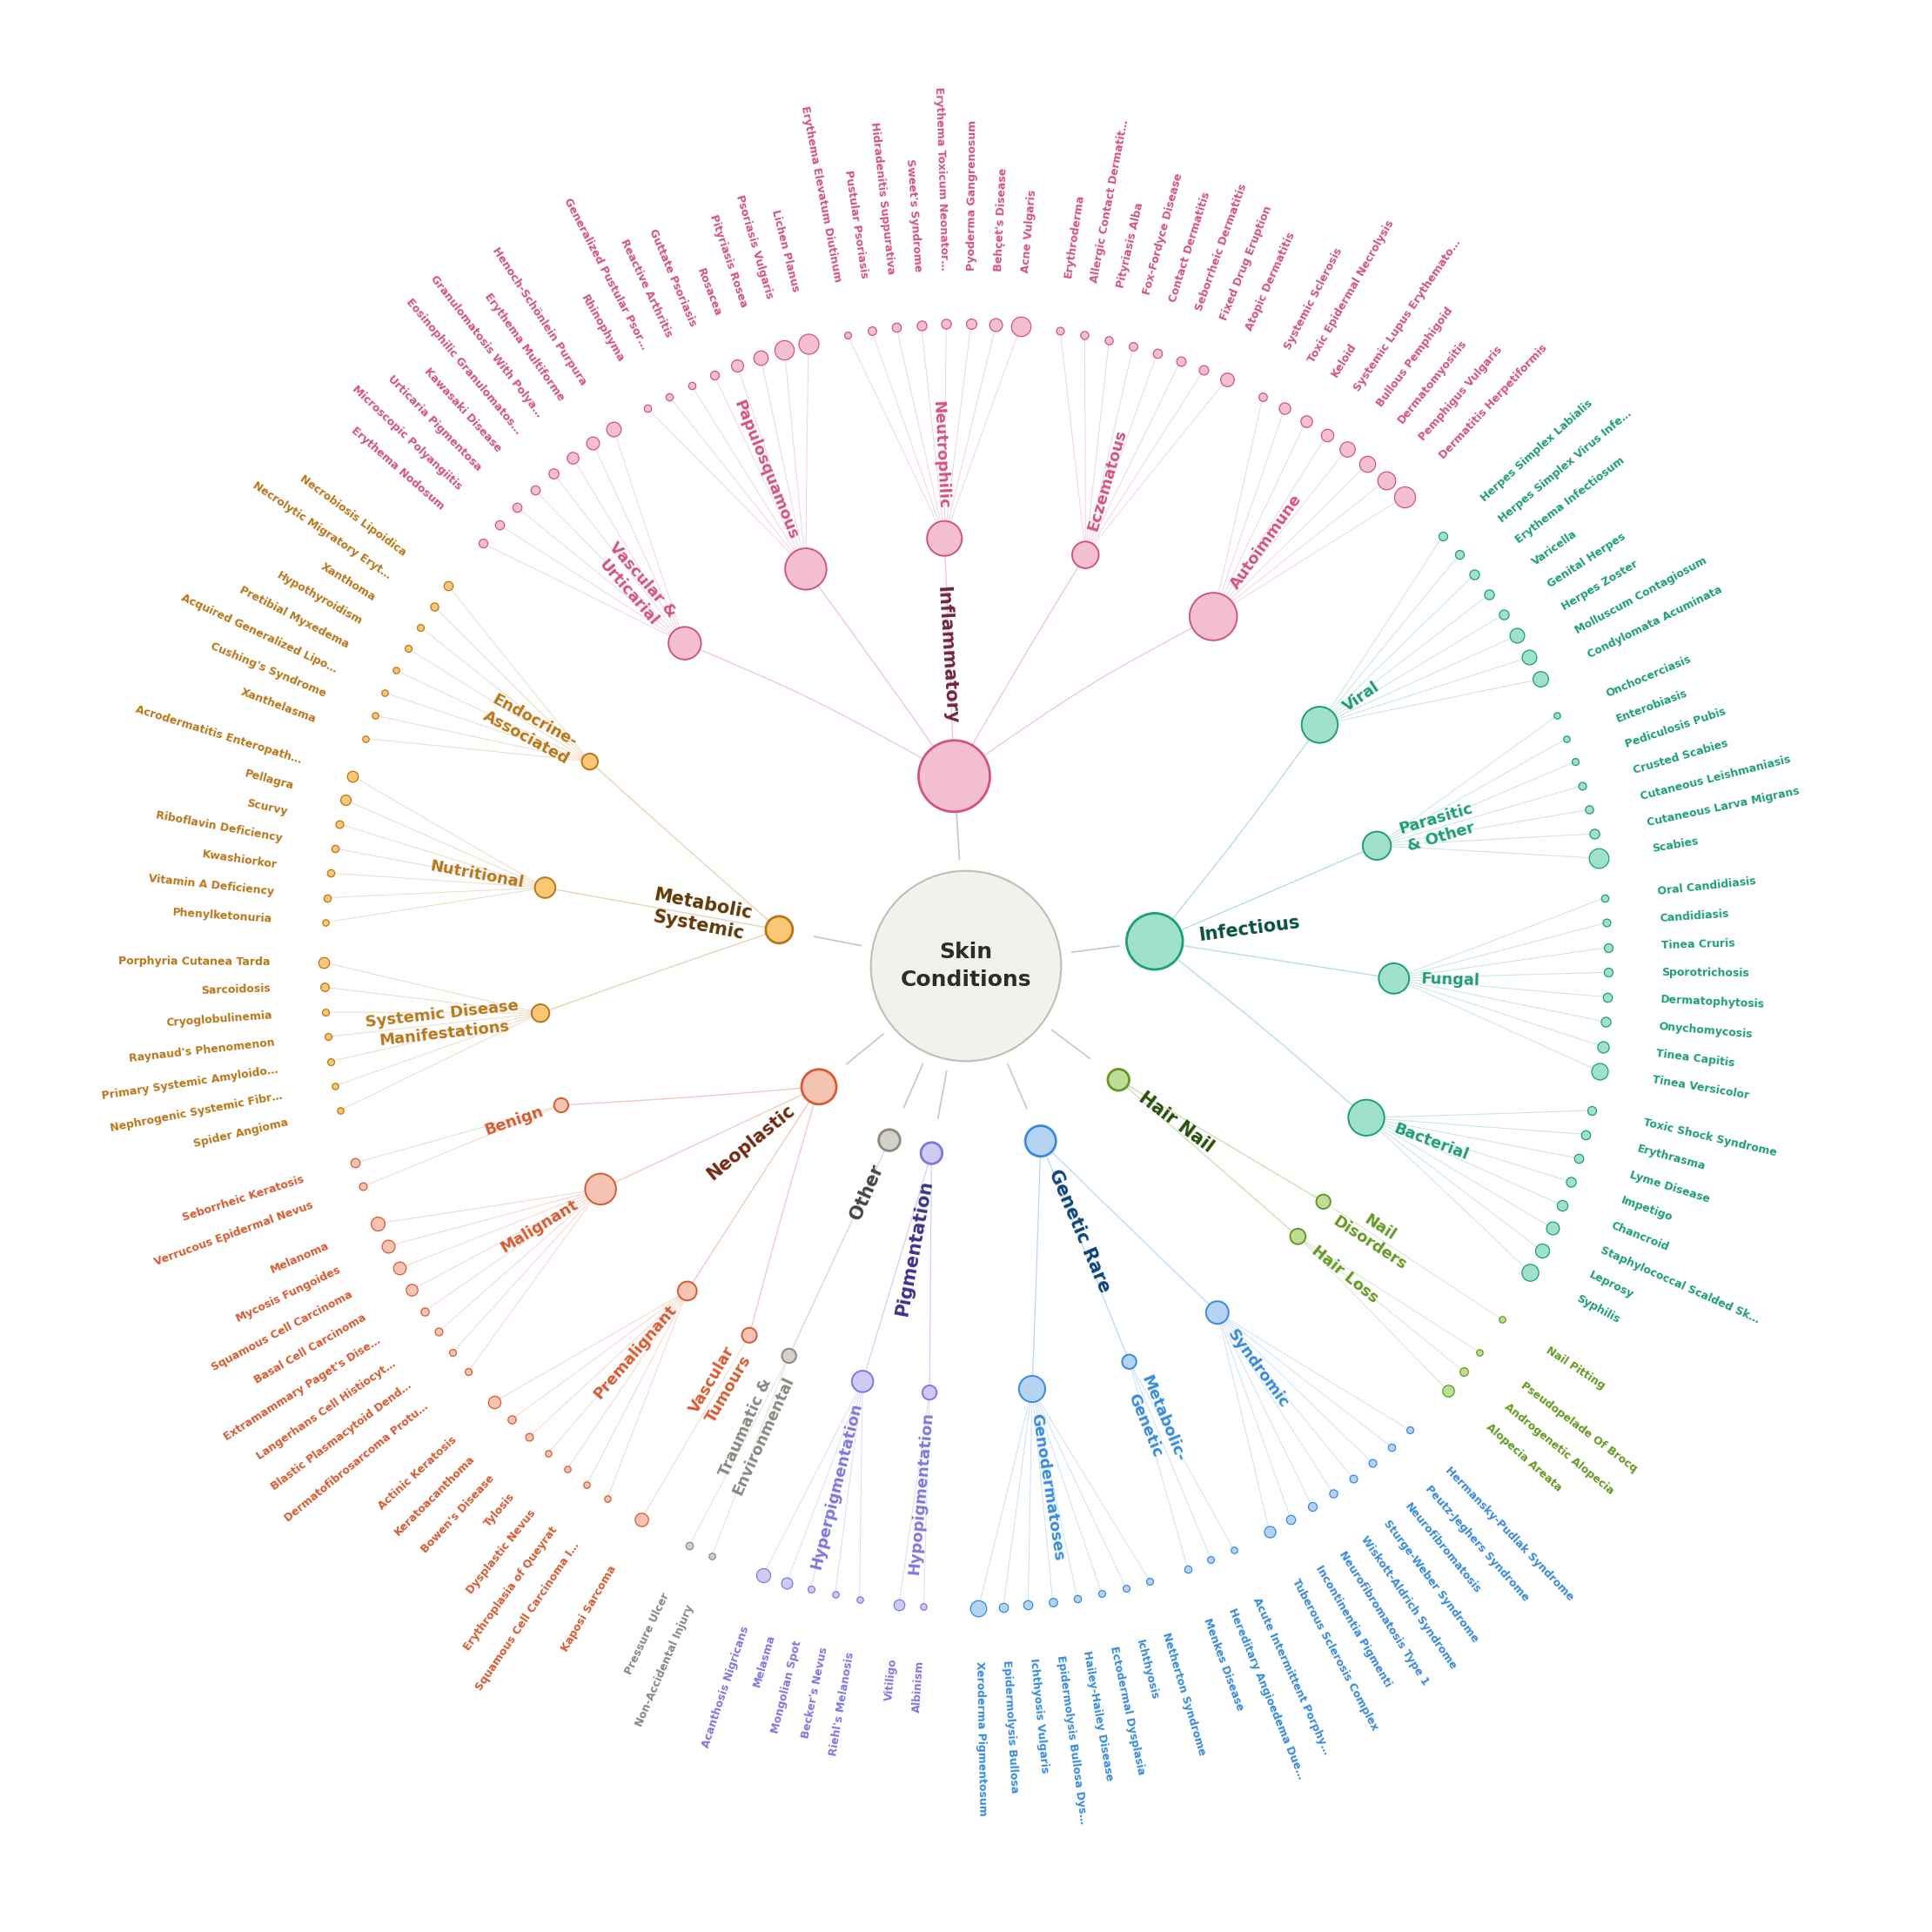

In [1]:
"""
Dermatology Radial Tree — driven from question_categories CSV(s)
Hierarchy: disease_category → disease_subcategory → canonical_disease

Supports combining multiple sources (e.g. MedQA + PubMed). Each source pairs a
categories CSV with its own retrieval dir; every source is subset against its
OWN retrieval dir before the sources are combined (question_ids overlap across
sources, so a subset must never be shared across them).
"""

import sys
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import pandas as pd

# ── CONFIG ────────────────────────────────────────────────────────────────────

# One entry per dataset. Each CSV is subset against its paired retrieval_dir,
# then all sources are concatenated for the plot. Use the *_cleaned CSVs — they
# carry disease_subcategory / canonical_disease.
SOURCES = [
    {"csv": "../results/question_categories_cleaned.csv",
     "retrieval_dir": "../results/retrieved_docs_medqa_qwenagent"},
    {"csv": "../results/question_categories_pubmed_cleaned.csv",
     "retrieval_dir": "../results/retrieved_docs_pubmed_qwenagent"},
]
OUTPUT_PNG      = "../plots/dermatology_radial_tree_combined.png"

TOP_N_DISEASES = 8          # max diseases shown per subcategory
MIN_DISEASE_N  = 2          # hide diseases with fewer questions than this

INNER_R  = 0.08             # root circle radius
MID_R    = 0.16             # category node ring
SUB_R    = 0.36             # subcategory node ring
OUTER_R  = 0.54             # disease dot ring
LABEL_R  = 0.585            # text start radius

CAT_GAP  = 0.6              # angular gap between categories (in leaf-slot units)
SUB_GAP  = 0.6              # angular gap between subcategories (in leaf-slot units)

CAT_NODE_R = 0.03          # radius of category circle nodes
SUB_NODE_R = 0.02          # radius of subcategory circle nodes

DOT_BASE  = 20              # min dot area (scatter s-units)
DOT_SCALE = 2.8             # scale factor on question count

FIG_SIZE  = (22, 22)
DPI       = 180

FONT_CAT     = 15.0         # category label fontsize
FONT_SUB     = 13.0          # subcategory label fontsize
FONT_DISEASE = 9.0          # disease leaf label fontsize

WRAP_THRESHOLD = 13         # wrap cat/sub labels longer than this many chars

# ── COLOR PALETTE — one colour per top-level category ────────────────────────

PALETTE = {
    "Inflammatory":      {"mid": "#D4537E", "light": "#F4C0D1", "dark": "#72243E"},
    "Infectious":        {"mid": "#1D9E75", "light": "#9FE1CB", "dark": "#085041"},
    "Neoplastic":        {"mid": "#D85A30", "light": "#F5C4B3", "dark": "#712B13"},
    "Metabolic Systemic":{"mid": "#BA7517", "light": "#FAC775", "dark": "#633806"},
    "Genetic Rare":      {"mid": "#378ADD", "light": "#B5D4F4", "dark": "#0C447C"},
    "Pigmentation":      {"mid": "#7F77DD", "light": "#CECBF6", "dark": "#3C3489"},
    "Hair Nail":         {"mid": "#639922", "light": "#C0DD97", "dark": "#27500A"},
    "Other":             {"mid": "#888780", "light": "#D3D1C7", "dark": "#444441"},
}
DEFAULT_PAL = {"mid": "#888780", "light": "#D3D1C7", "dark": "#444441"}

# ── LOAD & AGGREGATE ──────────────────────────────────────────────────────────

# For each source: collect question IDs where agentic retrieval was sufficient,
# subset that source's CSV to those IDs, then combine across sources.
frames = []
for src in SOURCES:
    sufficient_ids = set()
    for fname in os.listdir(src["retrieval_dir"]):
        d = json.load(open(os.path.join(src["retrieval_dir"], fname)))
        if d["retrieval_result"]["final_sufficient"] is True:
            sufficient_ids.add(int(d["question_id"]))
    sdf = pd.read_csv(src["csv"])
    sdf = sdf[sdf["question_id"].isin(sufficient_ids)]
    print(f"{src['retrieval_dir']}: sufficient={len(sufficient_ids)}, "
          f"{src['csv']} after subset={len(sdf)}")
    frames.append(sdf)

df = pd.concat(frames, ignore_index=True)
print(f"Combined questions: {len(df)}")

# Count questions per (category, subcategory, disease)
disease_counts = (
    df.groupby(["disease_category", "disease_subcategory", "canonical_disease"])
    .size()
    .reset_index(name="n")
)

# Drop "Unclassified" subcategories and very small disease counts
disease_counts = disease_counts[
    (disease_counts["disease_subcategory"] != "Unclassified") &
    (disease_counts["n"] >= MIN_DISEASE_N)
]

# Keep only TOP_N_DISEASES per subcategory (by question count)
disease_counts = (
    disease_counts
    .sort_values("n", ascending=False)
    .groupby(["disease_category", "disease_subcategory"], group_keys=False)
    .head(TOP_N_DISEASES)
    .sort_values(["disease_category", "disease_subcategory", "n"], ascending=[True, True, False])
    .reset_index(drop=True)
)

# ── BUILD TREE STRUCTURE ──────────────────────────────────────────────────────
# tree[cat][subcat] = [(disease, n), ...]

tree = {}
for _, row in disease_counts.iterrows():
    cat   = row["disease_category"]
    sub   = row["disease_subcategory"]
    dis   = row["canonical_disease"]
    n     = row["n"]
    tree.setdefault(cat, {}).setdefault(sub, []).append((dis, n))

cat_names = sorted(tree.keys())

# Aggregate question counts per category and subcategory
cat_n = {cat: sum(n for sub in tree[cat].values() for _, n in sub)
         for cat in cat_names}
sub_n = {(cat, sub): sum(n for _, n in diseases)
         for cat in cat_names for sub, diseases in tree[cat].items()}
max_cat_n = max(cat_n.values())
max_sub_n = max(sub_n.values())

# Aggregate question counts per category and subcategory
cat_n = {cat: sum(n for sub in tree[cat].values() for _, n in sub)
         for cat in cat_names}
sub_n = {(cat, sub): sum(n for _, n in diseases)
         for cat in cat_names for sub, diseases in tree[cat].items()}
max_cat_n = max(cat_n.values())
max_sub_n = max(sub_n.values())


# ── ANGULAR LAYOUT ────────────────────────────────────────────────────────────
# Leaves = individual diseases. CAT_GAP separates categories; SUB_GAP separates subcategories.

n_leaves  = sum(len(d) for cat in cat_names for d in tree[cat].values())
n_cats    = len(cat_names)
n_subs    = sum(len(tree[cat]) for cat in cat_names)
total_slots = n_leaves + CAT_GAP * n_cats + SUB_GAP * n_subs

def leaf_angle(i):
    return (i + 0.5) / total_slots * 2 * np.pi - np.pi / 2

# Pre-compute index ranges
leaf_idx = 0
cat_meta = {}
for cat in cat_names:
    cat_meta[cat] = {"start": leaf_idx, "subs": {}}
    for sub in tree[cat]:
        diseases = tree[cat][sub]
        sub_start = leaf_idx
        leaf_idx += len(diseases)
        cat_meta[cat]["subs"][sub] = {"start": sub_start, "end": leaf_idx}
        leaf_idx += SUB_GAP
    cat_meta[cat]["end"] = leaf_idx
    leaf_idx += CAT_GAP

def mid_angle(start, end):
    return (start + end) / 2 / total_slots * 2 * np.pi - np.pi / 2

def range_angle(idx):
    return idx / total_slots * 2 * np.pi - np.pi / 2

# ── DRAW ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
lim = LABEL_R + 0.22
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

def draw_bezier(ax, x0, y0, x1, y1, via_r, color, lw=0.7, alpha=0.5):
    """Curved branch: start → control at via_r along midpoint angle → end."""
    mx = (x0 + x1) / 2
    my = (y0 + y1) / 2
    mag = np.hypot(mx, my)
    if mag < 1e-9:
        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, alpha=alpha)
        return
    scale = via_r / mag
    cx, cy = mx * scale, my * scale
    verts = [(x0, y0), (cx, cy), (cx, cy), (x1, y1)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    patch = mpatches.PathPatch(
        Path(verts, codes), facecolor="none",
        edgecolor=color, linewidth=lw, alpha=alpha
    )
    ax.add_patch(patch)

def _wrap_text(text, threshold):
    """Split text into two lines near the midpoint word boundary."""
    if len(text) <= threshold:
        return text
    words = text.split()
    if len(words) >= 2:
        mid = len(text) / 2
        best_i, best_dist = 1, float('inf')
        for i in range(1, len(words)):
            dist = abs(len(' '.join(words[:i])) - mid)
            if dist < best_dist:
                best_dist, best_i = dist, i
        return ' '.join(words[:best_i]) + '\n' + ' '.join(words[best_i:])
    parts = text.split('-')
    if len(parts) >= 2:
        mid = len(parts) // 2
        return '-'.join(parts[:mid]) + '-\n' + '-'.join(parts[mid:])
    return text

def place_label(ax, r, angle, text, fontsize, color, fontweight="bold",
                max_chars=22, wrap=False):
    if wrap:
        text = _wrap_text(text, WRAP_THRESHOLD)
    elif len(text) > max_chars:
        text = text[:max_chars - 1] + "…"
    tx = np.cos(angle) * r
    ty = np.sin(angle) * r
    deg = np.degrees(angle)
    if -90 < deg <= 90:
        ha, rot = "left", deg
    else:
        ha, rot = "right", deg + 180
    ax.text(tx, ty, text, ha=ha, va="center",
            rotation=rot, rotation_mode="anchor",
            fontsize=fontsize, color=color,
            fontweight=fontweight, linespacing=1.3,
            multialignment="center")

# max n for dot scaling
max_n = disease_counts["n"].max()

# Root
root_circ = plt.Circle((0, 0), INNER_R, color="#f3f1ec",
                        ec="#c0bdb6", linewidth=1.5, zorder=5)
ax.add_patch(root_circ)
ax.text(0, 0, "Skin\nConditions", ha="center", va="center",
        fontsize=18, fontweight="bold", color="#2c2c2a", zorder=6,
        linespacing=1.4, multialignment="center")

for cat in cat_names:
    pal   = PALETTE.get(cat, DEFAULT_PAL)
    cmeta = cat_meta[cat]
    ca    = mid_angle(cmeta["start"], cmeta["end"])
    cx_   = np.cos(ca) * MID_R
    cy_   = np.sin(ca) * MID_R

    # Root → category
    x0 = np.cos(ca) * (INNER_R + 0.01)
    y0 = np.sin(ca) * (INNER_R + 0.01)
    x1 = np.cos(ca) * (MID_R - 0.03)
    y1 = np.sin(ca) * (MID_R - 0.03)
    ax.plot([x0, x1], [y0, y1], color="#c8c6be", lw=1.2, zorder=1)

    # Category node (radius scales with total question count)
    r_cat = max(CAT_NODE_R * np.sqrt(cat_n[cat] / max_cat_n), CAT_NODE_R * 0.3)
    cat_circ = plt.Circle((cx_, cy_), r_cat,
                           color=pal["light"], ec=pal["mid"],
                           linewidth=2.0, zorder=4)
    ax.add_patch(cat_circ)

    # Category label
    place_label(ax, MID_R + r_cat + 0.014, ca, cat, fontsize=FONT_CAT,
                color=pal["dark"], fontweight="bold", wrap=True)

    for sub, smeta in cmeta["subs"].items():
        sa    = mid_angle(smeta["start"], smeta["end"])
        sx_   = np.cos(sa) * SUB_R
        sy_   = np.sin(sa) * SUB_R

        # Category → subcategory branch
        draw_bezier(ax, cx_, cy_, sx_, sy_,
                    via_r=(MID_R + SUB_R) / 2,
                    color=pal["mid"], lw=0.9, alpha=0.35)

        # Subcategory node (radius scales with total question count)
        r_sub = max(SUB_NODE_R * np.sqrt(sub_n[(cat, sub)] / max_sub_n), SUB_NODE_R * 0.3)
        sub_circ = plt.Circle((sx_, sy_), r_sub,
                               color=pal["light"], ec=pal["mid"],
                               linewidth=1.4, zorder=4)
        ax.add_patch(sub_circ)

        # Subcategory label
        place_label(ax, SUB_R + r_sub + 0.010, sa, sub, fontsize=FONT_SUB,
                    color=pal["mid"], fontweight="bold", wrap=True)

        diseases = tree[cat][sub]
        for di, (dname, dn) in enumerate(diseases):
            li  = smeta["start"] + di
            la  = leaf_angle(li)
            lx_ = np.cos(la) * OUTER_R
            ly_ = np.sin(la) * OUTER_R

            # Subcategory → leaf branch (bezier)
            draw_bezier(ax, sx_, sy_, lx_, ly_,
                        via_r=(SUB_R + OUTER_R) / 2,
                        color=pal["mid"], lw=0.65, alpha=0.28)

            # Disease dot, sized by question count
            dot_s = DOT_BASE + (dn / max_n) * (DOT_BASE * DOT_SCALE * 5)
            ax.scatter(lx_, ly_, s=dot_s,
                       color=pal["light"], edgecolors=pal["mid"],
                       linewidths=0.9, zorder=5)

            # Leaf label
            place_label(ax, LABEL_R, la, dname,
                        fontsize=FONT_DISEASE, color=pal["mid"], max_chars=26)


plt.tight_layout(pad=0)
plt.savefig(OUTPUT_PNG, dpi=DPI, bbox_inches="tight", facecolor="white", pad_inches=0.00)
print(f"Saved → {OUTPUT_PNG}")

Reader-study question_ids: 320
Reader-study questions in tree: 320
Saved → ../plots/dermatology_radial_tree_reader_study.png


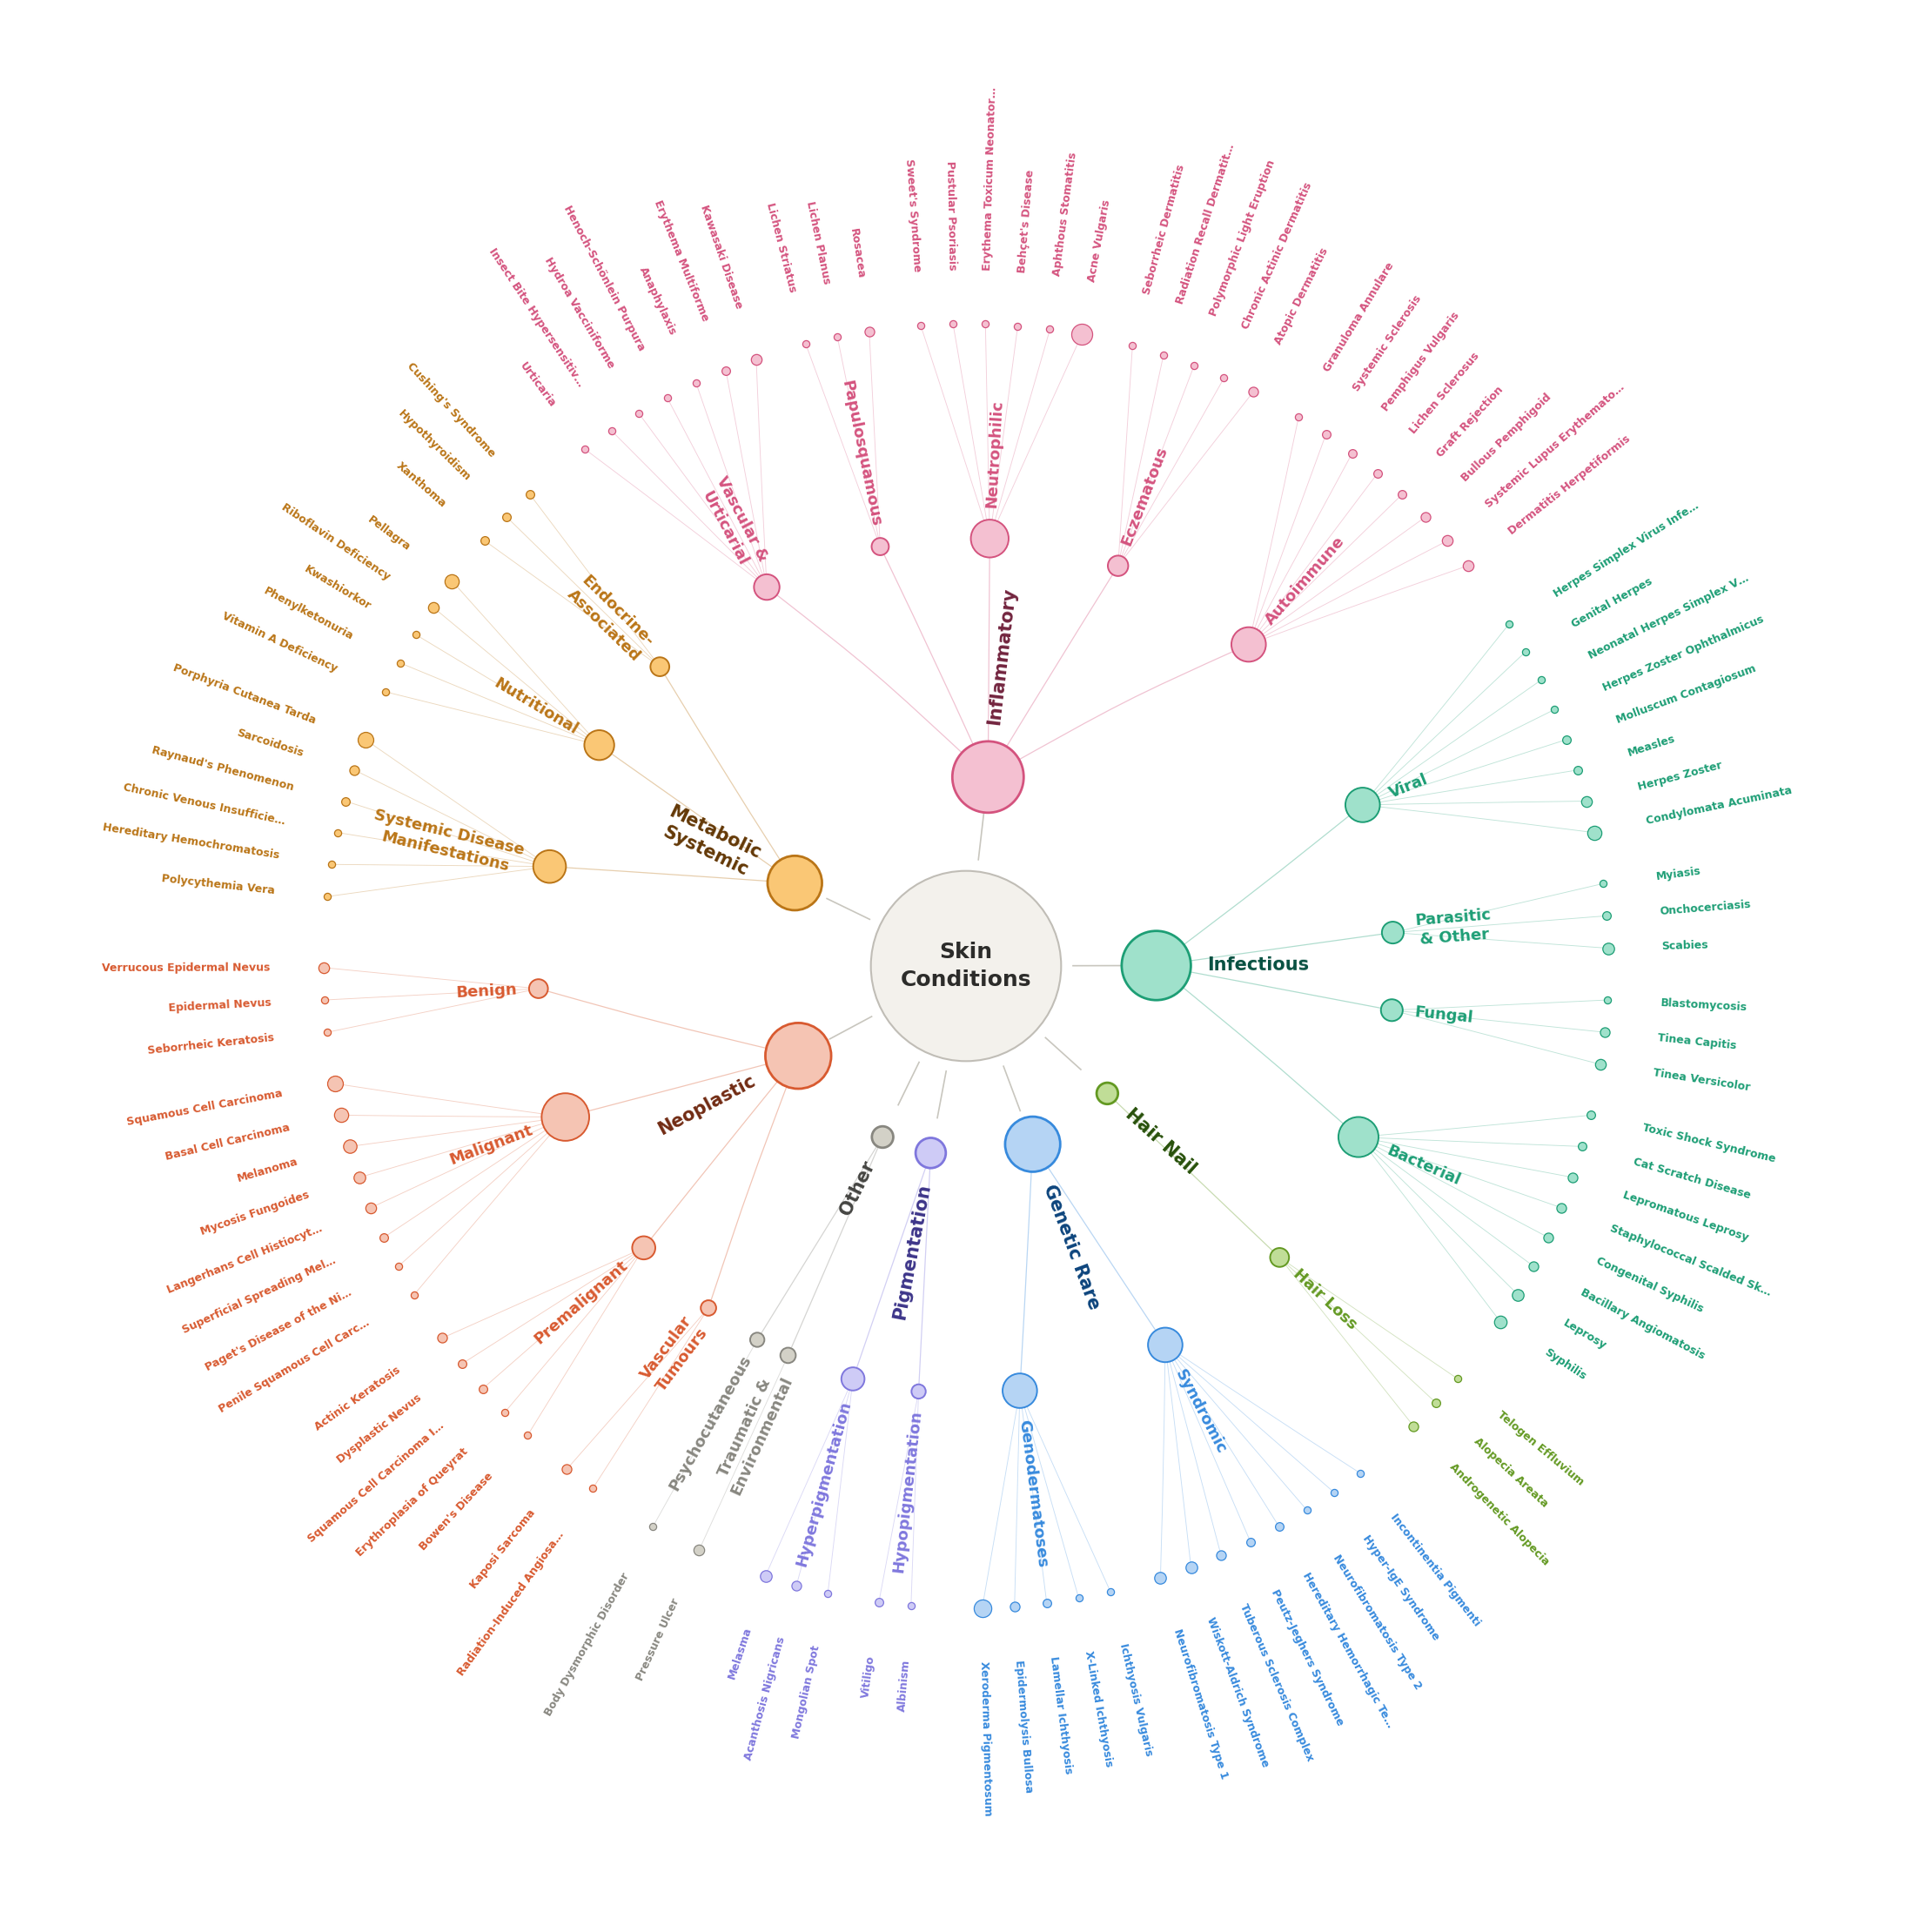

In [2]:
"""
Dermatology Radial Tree — READER-STUDY questions only.

Same layout/drawing as the combined-source cell above, but instead of
subsetting by agentic-retrieval sufficiency across MedQA + PubMed, this
subsets a single source (MedQA — the reader study drew only from
question_categories_cleaned.csv) to the question_ids actually used in the
reader study, collected from reader_study/group_*/group_*.json.
"""

import sys
import glob
import json
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.path import Path
import pandas as pd

# ── CONFIG ────────────────────────────────────────────────────────────────────

CATEGORIES_CSV   = "../results/question_categories_cleaned.csv"   # reader study = MedQA only
READER_STUDY_GLOB = "../reader_study/group_*/group_*.json"
OUTPUT_PNG       = "../plots/dermatology_radial_tree_reader_study.png"

TOP_N_DISEASES = 8          # max diseases shown per subcategory
MIN_DISEASE_N  = 1          # hide diseases with fewer questions than this (1 = show all)

INNER_R  = 0.08             # root circle radius
MID_R    = 0.16             # category node ring
SUB_R    = 0.36             # subcategory node ring
OUTER_R  = 0.54             # disease dot ring
LABEL_R  = 0.585            # text start radius

CAT_GAP  = 0.6              # angular gap between categories (in leaf-slot units)
SUB_GAP  = 0.6              # angular gap between subcategories (in leaf-slot units)

CAT_NODE_R = 0.03          # radius of category circle nodes
SUB_NODE_R = 0.02          # radius of subcategory circle nodes

DOT_BASE  = 20              # min dot area (scatter s-units)
DOT_SCALE = 2.8             # scale factor on question count

FIG_SIZE  = (22, 22)
DPI       = 180

FONT_CAT     = 15.0         # category label fontsize
FONT_SUB     = 13.0          # subcategory label fontsize
FONT_DISEASE = 9.0          # disease leaf label fontsize

WRAP_THRESHOLD = 13         # wrap cat/sub labels longer than this many chars

# ── COLOR PALETTE — one colour per top-level category ────────────────────────

PALETTE = {
    "Inflammatory":      {"mid": "#D4537E", "light": "#F4C0D1", "dark": "#72243E"},
    "Infectious":        {"mid": "#1D9E75", "light": "#9FE1CB", "dark": "#085041"},
    "Neoplastic":        {"mid": "#D85A30", "light": "#F5C4B3", "dark": "#712B13"},
    "Metabolic Systemic":{"mid": "#BA7517", "light": "#FAC775", "dark": "#633806"},
    "Genetic Rare":      {"mid": "#378ADD", "light": "#B5D4F4", "dark": "#0C447C"},
    "Pigmentation":      {"mid": "#7F77DD", "light": "#CECBF6", "dark": "#3C3489"},
    "Hair Nail":         {"mid": "#639922", "light": "#C0DD97", "dark": "#27500A"},
    "Other":             {"mid": "#888780", "light": "#D3D1C7", "dark": "#444441"},
}
DEFAULT_PAL = {"mid": "#888780", "light": "#D3D1C7", "dark": "#444441"}

# ── LOAD & AGGREGATE (reader-study questions only) ────────────────────────────

# Collect the question_ids actually used in the reader study (across all groups)
reader_ids = set()
for f in glob.glob(READER_STUDY_GLOB):
    reader_ids |= {int(q["question_id"]) for q in json.load(open(f))}
print(f"Reader-study question_ids: {len(reader_ids)}")

df = pd.read_csv(CATEGORIES_CSV)
df = df[df["question_id"].isin(reader_ids)].reset_index(drop=True)
print(f"Reader-study questions in tree: {len(df)}")

# Count questions per (category, subcategory, disease)
disease_counts = (
    df.groupby(["disease_category", "disease_subcategory", "canonical_disease"])
    .size()
    .reset_index(name="n")
)

# Drop "Unclassified" subcategories and very small disease counts
disease_counts = disease_counts[
    (disease_counts["disease_subcategory"] != "Unclassified") &
    (disease_counts["n"] >= MIN_DISEASE_N)
]

# Keep only TOP_N_DISEASES per subcategory (by question count)
disease_counts = (
    disease_counts
    .sort_values("n", ascending=False)
    .groupby(["disease_category", "disease_subcategory"], group_keys=False)
    .head(TOP_N_DISEASES)
    .sort_values(["disease_category", "disease_subcategory", "n"], ascending=[True, True, False])
    .reset_index(drop=True)
)

# ── BUILD TREE STRUCTURE ──────────────────────────────────────────────────────
# tree[cat][subcat] = [(disease, n), ...]

tree = {}
for _, row in disease_counts.iterrows():
    cat   = row["disease_category"]
    sub   = row["disease_subcategory"]
    dis   = row["canonical_disease"]
    n     = row["n"]
    tree.setdefault(cat, {}).setdefault(sub, []).append((dis, n))

cat_names = sorted(tree.keys())

# Aggregate question counts per category and subcategory
cat_n = {cat: sum(n for sub in tree[cat].values() for _, n in sub)
         for cat in cat_names}
sub_n = {(cat, sub): sum(n for _, n in diseases)
         for cat in cat_names for sub, diseases in tree[cat].items()}
max_cat_n = max(cat_n.values())
max_sub_n = max(sub_n.values())


# ── ANGULAR LAYOUT ────────────────────────────────────────────────────────────
# Leaves = individual diseases. CAT_GAP separates categories; SUB_GAP separates subcategories.

n_leaves  = sum(len(d) for cat in cat_names for d in tree[cat].values())
n_cats    = len(cat_names)
n_subs    = sum(len(tree[cat]) for cat in cat_names)
total_slots = n_leaves + CAT_GAP * n_cats + SUB_GAP * n_subs

def leaf_angle(i):
    return (i + 0.5) / total_slots * 2 * np.pi - np.pi / 2

# Pre-compute index ranges
leaf_idx = 0
cat_meta = {}
for cat in cat_names:
    cat_meta[cat] = {"start": leaf_idx, "subs": {}}
    for sub in tree[cat]:
        diseases = tree[cat][sub]
        sub_start = leaf_idx
        leaf_idx += len(diseases)
        cat_meta[cat]["subs"][sub] = {"start": sub_start, "end": leaf_idx}
        leaf_idx += SUB_GAP
    cat_meta[cat]["end"] = leaf_idx
    leaf_idx += CAT_GAP

def mid_angle(start, end):
    return (start + end) / 2 / total_slots * 2 * np.pi - np.pi / 2

def range_angle(idx):
    return idx / total_slots * 2 * np.pi - np.pi / 2

# ── DRAW ──────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=FIG_SIZE, facecolor="white")
ax.set_aspect("equal")
ax.axis("off")
lim = LABEL_R + 0.22
ax.set_xlim(-lim, lim)
ax.set_ylim(-lim, lim)

def draw_bezier(ax, x0, y0, x1, y1, via_r, color, lw=0.7, alpha=0.5):
    """Curved branch: start → control at via_r along midpoint angle → end."""
    mx = (x0 + x1) / 2
    my = (y0 + y1) / 2
    mag = np.hypot(mx, my)
    if mag < 1e-9:
        ax.plot([x0, x1], [y0, y1], color=color, lw=lw, alpha=alpha)
        return
    scale = via_r / mag
    cx, cy = mx * scale, my * scale
    verts = [(x0, y0), (cx, cy), (cx, cy), (x1, y1)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    patch = mpatches.PathPatch(
        Path(verts, codes), facecolor="none",
        edgecolor=color, linewidth=lw, alpha=alpha
    )
    ax.add_patch(patch)

def _wrap_text(text, threshold):
    """Split text into two lines near the midpoint word boundary."""
    if len(text) <= threshold:
        return text
    words = text.split()
    if len(words) >= 2:
        mid = len(text) / 2
        best_i, best_dist = 1, float('inf')
        for i in range(1, len(words)):
            dist = abs(len(' '.join(words[:i])) - mid)
            if dist < best_dist:
                best_dist, best_i = dist, i
        return ' '.join(words[:best_i]) + '\n' + ' '.join(words[best_i:])
    parts = text.split('-')
    if len(parts) >= 2:
        mid = len(parts) // 2
        return '-'.join(parts[:mid]) + '-\n' + '-'.join(parts[mid:])
    return text

def place_label(ax, r, angle, text, fontsize, color, fontweight="bold",
                max_chars=22, wrap=False):
    if wrap:
        text = _wrap_text(text, WRAP_THRESHOLD)
    elif len(text) > max_chars:
        text = text[:max_chars - 1] + "…"
    tx = np.cos(angle) * r
    ty = np.sin(angle) * r
    deg = np.degrees(angle)
    if -90 < deg <= 90:
        ha, rot = "left", deg
    else:
        ha, rot = "right", deg + 180
    ax.text(tx, ty, text, ha=ha, va="center",
            rotation=rot, rotation_mode="anchor",
            fontsize=fontsize, color=color,
            fontweight=fontweight, linespacing=1.3,
            multialignment="center")

# max n for dot scaling
max_n = disease_counts["n"].max()

# Root
root_circ = plt.Circle((0, 0), INNER_R, color="#f3f1ec",
                        ec="#c0bdb6", linewidth=1.5, zorder=5)
ax.add_patch(root_circ)
ax.text(0, 0, "Skin\nConditions", ha="center", va="center",
        fontsize=18, fontweight="bold", color="#2c2c2a", zorder=6,
        linespacing=1.4, multialignment="center")

for cat in cat_names:
    pal   = PALETTE.get(cat, DEFAULT_PAL)
    cmeta = cat_meta[cat]
    ca    = mid_angle(cmeta["start"], cmeta["end"])
    cx_   = np.cos(ca) * MID_R
    cy_   = np.sin(ca) * MID_R

    # Root → category
    x0 = np.cos(ca) * (INNER_R + 0.01)
    y0 = np.sin(ca) * (INNER_R + 0.01)
    x1 = np.cos(ca) * (MID_R - 0.03)
    y1 = np.sin(ca) * (MID_R - 0.03)
    ax.plot([x0, x1], [y0, y1], color="#c8c6be", lw=1.2, zorder=1)

    # Category node (radius scales with total question count)
    r_cat = max(CAT_NODE_R * np.sqrt(cat_n[cat] / max_cat_n), CAT_NODE_R * 0.3)
    cat_circ = plt.Circle((cx_, cy_), r_cat,
                           color=pal["light"], ec=pal["mid"],
                           linewidth=2.0, zorder=4)
    ax.add_patch(cat_circ)

    # Category label
    place_label(ax, MID_R + r_cat + 0.014, ca, cat, fontsize=FONT_CAT,
                color=pal["dark"], fontweight="bold", wrap=True)

    for sub, smeta in cmeta["subs"].items():
        sa    = mid_angle(smeta["start"], smeta["end"])
        sx_   = np.cos(sa) * SUB_R
        sy_   = np.sin(sa) * SUB_R

        # Category → subcategory branch
        draw_bezier(ax, cx_, cy_, sx_, sy_,
                    via_r=(MID_R + SUB_R) / 2,
                    color=pal["mid"], lw=0.9, alpha=0.35)

        # Subcategory node (radius scales with total question count)
        r_sub = max(SUB_NODE_R * np.sqrt(sub_n[(cat, sub)] / max_sub_n), SUB_NODE_R * 0.3)
        sub_circ = plt.Circle((sx_, sy_), r_sub,
                               color=pal["light"], ec=pal["mid"],
                               linewidth=1.4, zorder=4)
        ax.add_patch(sub_circ)

        # Subcategory label
        place_label(ax, SUB_R + r_sub + 0.010, sa, sub, fontsize=FONT_SUB,
                    color=pal["mid"], fontweight="bold", wrap=True)

        diseases = tree[cat][sub]
        for di, (dname, dn) in enumerate(diseases):
            li  = smeta["start"] + di
            la  = leaf_angle(li)
            lx_ = np.cos(la) * OUTER_R
            ly_ = np.sin(la) * OUTER_R

            # Subcategory → leaf branch (bezier)
            draw_bezier(ax, sx_, sy_, lx_, ly_,
                        via_r=(SUB_R + OUTER_R) / 2,
                        color=pal["mid"], lw=0.65, alpha=0.28)

            # Disease dot, sized by question count
            dot_s = DOT_BASE + (dn / max_n) * (DOT_BASE * DOT_SCALE * 5)
            ax.scatter(lx_, ly_, s=dot_s,
                       color=pal["light"], edgecolors=pal["mid"],
                       linewidths=0.9, zorder=5)

            # Leaf label
            place_label(ax, LABEL_R, la, dname,
                        fontsize=FONT_DISEASE, color=pal["mid"], max_chars=26)


plt.tight_layout(pad=0)
plt.savefig(OUTPUT_PNG, dpi=DPI, bbox_inches="tight", facecolor="white", pad_inches=0.00)
print(f"Saved → {OUTPUT_PNG}")